<div style="
    background: linear-gradient(135deg, #8B1E3F 0%, #C44569 55%, #F8A5C2 100%);
    padding: 50px 35px;
    border-radius: 22px;
    color: white;
    text-align: center;
    box-shadow: 0 8px 25px rgba(139, 30, 63, 0.25);
">

<div style="font-size: 14px; letter-spacing: 3px; text-transform: uppercase; opacity: 0.9; margin-bottom: 15px;">
    BinX Tech — AI & ML Internship · Week 6 · Day 2
</div>

<h1 style="font-size: 38px; margin: 0; font-weight: 700;">
    Activations, Forward Propagation & Loss
</h1>

<p style="font-size: 20px; margin-top: 12px; opacity: 0.95;">
    Cardiac Patient Monitoring System — Heart Disease Prediction
</p>

</div>

## 1. Why Do We Need Activation Functions?

A neural network without activation functions is just a linear model —
no matter how many layers it has.

Here is why: stacking linear operations always produces another linear
operation. Mathematically, if every layer computes:

**output = (inputs × weights) + bias**

then 10 layers of this is still equivalent to one single linear
transformation. The extra layers add no new learning capacity.

The activation function breaks this pattern by introducing
**non-linearity** after each neuron's weighted sum. This is the single
ingredient that allows a neural network to learn complex, curved
decision boundaries — patterns that a straight line could never capture.

Without activation functions → the network is linear regression in disguise.  
With activation functions → the network can learn almost any pattern.

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# We calculate the value of a single linear layer twice and check if the result is the same.
x = np.array([1.0, 2.0])

W1 = np.array([[0.5, -0.2],
                [0.3,  0.8]])
b1 = np.array([0.1, -0.1])

W2 = np.array([[1.0, 0.0],
                [0.0, 1.0]])
b2 = np.array([0.0, 0.0])

# Two linear layers stacked
layer1 = x @ W1 + b1
layer2 = layer1 @ W2 + b2

# One equivalent linear transformation
W_combined = W1 @ W2
b_combined  = b1 @ W2 + b2
direct      = x @ W_combined + b_combined

print("Two linear layers stacked :", layer2.round(4))
print("One equivalent layer      :", direct.round(4))
print("\nIdentical? →", np.allclose(layer2, direct))
print("\nConclusion: stacking linear layers adds no extra capacity.")

Two linear layers stacked : [1.2 1.3]
One equivalent layer      : [1.2 1.3]

Identical? → True

Conclusion: stacking linear layers adds no extra capacity.


---

## 2. ReLU — Rectified Linear Unit

ReLU is the most widely used activation function in hidden layers.
The formula is simple:

**ReLU(z) = max(0, z)**

- If the input is positive → pass it through unchanged
- If the input is negative → output zero

That is all. Despite its simplicity, ReLU works remarkably well in
practice and is the default choice for hidden layers in most networks.

**Why ReLU works well:**
- Computationally cheap — no exponentials, just a comparison
- Does not saturate for positive values — gradients flow cleanly
- Sparse activation — not all neurons fire at once, which helps
  the network learn distinct features

**One known issue — Dead ReLU:**
If a neuron's input is always negative, it always outputs zero and
its weights never update. This is called a "dead neuron." It is
manageable in practice by using good weight initialization and
keeping the learning rate reasonable.

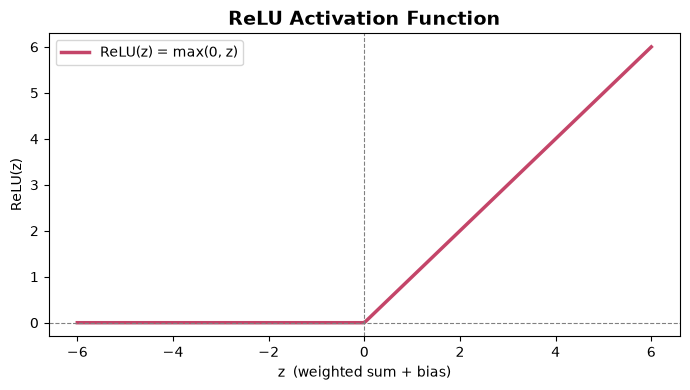

Input z       : [-3.  -0.5  0.   1.2  4. ]
ReLU output   : [0.  0.  0.  1.2 4. ]


In [60]:
def relu(z):
    return np.maximum(0, z)

z = np.linspace(-6, 6, 300)

plt.figure(figsize=(7, 4))
plt.plot(z, relu(z), color="#C44569", linewidth=2.5, label="ReLU(z) = max(0, z)")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.axvline(0, color="gray", linewidth=0.8, linestyle="--")
plt.title("ReLU Activation Function", fontsize=14, fontweight="bold")
plt.xlabel("z  (weighted sum + bias)")
plt.ylabel("ReLU(z)")
plt.legend()
plt.tight_layout()
plt.show()

# مثال عددي
examples = np.array([-3.0, -0.5, 0.0, 1.2, 4.0])
print("Input z       :", examples)
print("ReLU output   :", relu(examples))

---

## 3. Sigmoid

Sigmoid squashes any input into a value between 0 and 1.
This makes it a natural choice for the output layer in binary
classification — the output is interpreted directly as a probability.

**Formula:**

**σ(z) = 1 / (1 + e⁻ᶻ)**

- Large positive z → output close to 1
- Large negative z → output close to 0
- z = 0 → output = 0.5

**Where to use it:**
- Output layer for binary classification tasks
- Not recommended for hidden layers — it suffers from the
  vanishing gradient problem: for very large or very small inputs,
  the gradient becomes nearly zero and weights stop updating.

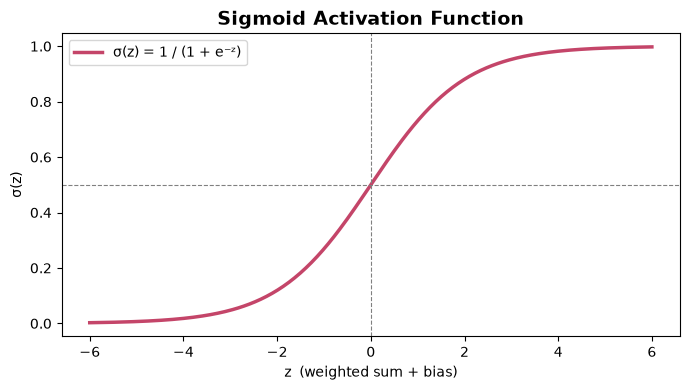

Input z        : [-4. -1.  0.  1.  4.]
Sigmoid output : [0.018  0.2689 0.5    0.7311 0.982 ]


In [61]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-6, 6, 300)

plt.figure(figsize=(7, 4))
plt.plot(z, sigmoid(z), color="#C44569", linewidth=2.5,
         label="σ(z) = 1 / (1 + e⁻ᶻ)")
plt.axhline(0.5, color="gray", linewidth=0.8, linestyle="--")
plt.axvline(0,   color="gray", linewidth=0.8, linestyle="--")
plt.title("Sigmoid Activation Function", fontsize=14, fontweight="bold")
plt.xlabel("z  (weighted sum + bias)")
plt.ylabel("σ(z)")
plt.legend()
plt.tight_layout()
plt.show()

examples = np.array([-4.0, -1.0, 0.0, 1.0, 4.0])
print("Input z        :", examples)
print("Sigmoid output :", sigmoid(examples).round(4))

---

## 4. Tanh — Hyperbolic Tangent

Tanh is similar to sigmoid but squashes inputs into the range [-1, 1]
instead of [0, 1]. Because its output is centered around zero,
it tends to produce stronger gradients than sigmoid during training.

**Formula:**

**tanh(z) = (eᶻ − e⁻ᶻ) / (eᶻ + e⁻ᶻ)**

- Large positive z → output close to +1
- Large negative z → output close to −1
- z = 0 → output = 0

**Where to use it:**
- Hidden layers when zero-centered output is beneficial
- Still suffers from vanishing gradients at the extremes,
  which is why ReLU is usually preferred in modern networks

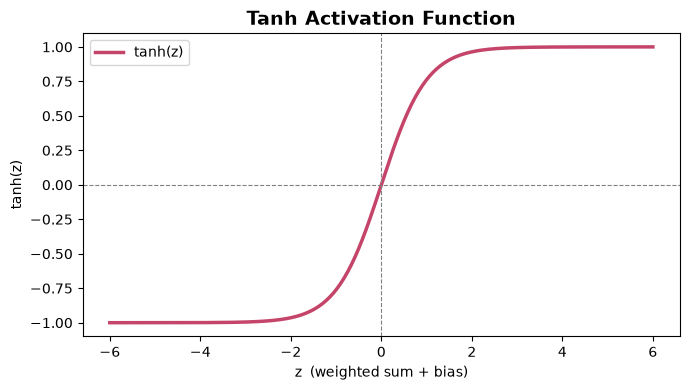

Input z      : [-4. -1.  0.  1.  4.]
Tanh output  : [-0.9993 -0.7616  0.      0.7616  0.9993]


In [62]:
def tanh(z):
    return np.tanh(z)

z = np.linspace(-6, 6, 300)

plt.figure(figsize=(7, 4))
plt.plot(z, tanh(z), color="#C44569", linewidth=2.5,
         label="tanh(z)")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.axvline(0, color="gray", linewidth=0.8, linestyle="--")
plt.title("Tanh Activation Function", fontsize=14, fontweight="bold")
plt.xlabel("z  (weighted sum + bias)")
plt.ylabel("tanh(z)")
plt.legend()
plt.tight_layout()
plt.show()

examples = np.array([-4.0, -1.0, 0.0, 1.0, 4.0])
print("Input z      :", examples)
print("Tanh output  :", tanh(examples).round(4))

---

## 5. Softmax

Softmax is used in the output layer for multi-class classification.
It takes a vector of raw scores and converts them into a probability
distribution — all outputs sum to exactly 1.

**Formula:**

**Softmax(zᵢ) = eᶻⁱ / Σ eᶻʲ**

**Example:**
If the network outputs [2.0, 1.0, 0.5] for three classes:
- Softmax converts these into probabilities: [0.59, 0.24, 0.17]
- The model predicts class 0 with 59% confidence

**Where to use it:**
- Output layer for multi-class classification only
- Not used in hidden layers
- Not needed for binary classification — sigmoid handles that case

Raw scores (logits) : [2.  1.  0.5]
Softmax probabilities: [0.6285 0.2312 0.1402]
Sum of probabilities : 1.0


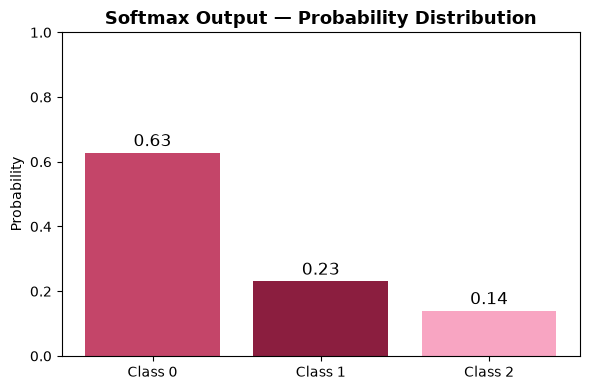

In [63]:
def softmax(z):
    e_z = np.exp(z - np.max(z))   # stability trick
    return e_z / e_z.sum()

# مثال: 3 classes
raw_scores = np.array([2.0, 1.0, 0.5])
probs      = softmax(raw_scores)

print("Raw scores (logits) :", raw_scores)
print("Softmax probabilities:", probs.round(4))
print("Sum of probabilities :", probs.sum().round(4))

# Plot
plt.figure(figsize=(6, 4))
plt.bar(["Class 0", "Class 1", "Class 2"], probs,
        color=["#C44569", "#8B1E3F", "#F8A5C2"])
plt.title("Softmax Output — Probability Distribution",
          fontsize=13, fontweight="bold")
plt.ylabel("Probability")
plt.ylim(0, 1)
for i, p in enumerate(probs):
    plt.text(i, p + 0.02, f"{p:.2f}", ha="center", fontsize=12)
plt.tight_layout()
plt.show()

---

## 6. Comparing Activation Functions

The plot below shows all four activation functions on the same axes.
Each one transforms the input z differently, which determines
where and why each is useful.

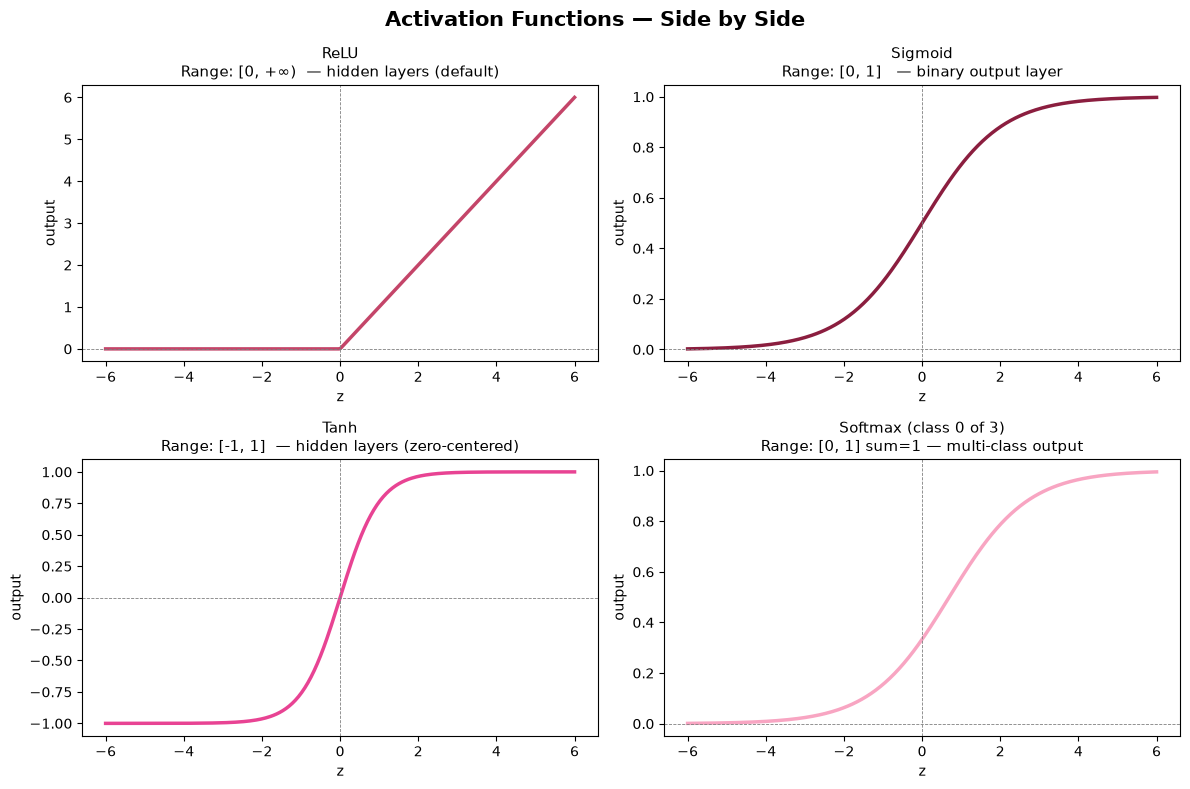

In [64]:
z = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Activation Functions — Side by Side",
             fontsize=15, fontweight="bold")

configs = [
    (relu(z),    "ReLU",    "#C44569", "[0, +∞)  — hidden layers (default)"),
    (sigmoid(z), "Sigmoid", "#8B1E3F", "[0, 1]   — binary output layer"),
    (tanh(z),    "Tanh",    "#E84393", "[-1, 1]  — hidden layers (zero-centered)"),
]

softmax_z = np.array([z, np.zeros_like(z), np.zeros_like(z)]).T
softmax_vals = np.array([softmax(row)[0] for row in softmax_z])

all_configs = configs + [
    (softmax_vals, "Softmax (class 0 of 3)", "#F8A5C2",
     "[0, 1] sum=1 — multi-class output")
]

for ax, (vals, name, color, note) in zip(axes.flat, all_configs):
    ax.plot(z, vals, color=color, linewidth=2.5)
    ax.axhline(0, color="gray", linewidth=0.6, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.6, linestyle="--")
    ax.set_title(f"{name}\nRange: {note}", fontsize=11)
    ax.set_xlabel("z")
    ax.set_ylabel("output")

plt.tight_layout()
plt.show()

---

## 7. How to Choose an Activation Function?

The choice follows a simple two-step rule:

**Step 1 — Hidden layers:**
Use ReLU by default. It is fast, effective, and works well in the
vast majority of cases. Switch to tanh only if zero-centered output
is specifically needed.

**Step 2 — Output layer:**
The output activation depends entirely on the task:

| Task | Output Activation | Why |
|------|-------------------|-----|
| Binary classification | Sigmoid | Output is a probability between 0 and 1 |
| Multi-class classification | Softmax | Outputs a probability distribution over all classes |
| Regression | None (linear) | Output is an unbounded real number |

**The rule in one sentence:**
> ReLU in every hidden layer. Sigmoid or Softmax only at the output,
> chosen by the task type.

---

## 8. Forward Propagation

Forward propagation is how the network makes a prediction.
Data enters the input layer and flows forward through each layer
in order — each layer computes its weighted sum, adds the bias,
and applies its activation function — until the output layer
produces the final prediction.

**The flow for a 2-hidden-layer network:**

```
Input X
↓
Layer 1: z1 = X · W1 + b1 → a1 = ReLU(z1)
↓
Layer 2: z2 = a1 · W2 + b2 → a2 = ReLU(z2)
↓
Output: z3 = a2 · W3 + b3 → ŷ = sigmoid(z3)
```

Each layer receives the activations of the previous layer as its
input. The final output ŷ is the network's prediction.

Forward propagation is the first half of every training step —
after it, the loss is computed, and then backpropagation runs
in reverse to update the weights (covered in Day 3).

---

## 9. Loss Functions

After forward propagation produces a prediction ŷ, the loss function
measures how wrong that prediction is by comparing it to the true
label y. Training is the process of minimizing this loss.

**Binary Cross-Entropy** — for binary classification:

**L = −[y · log(ŷ) + (1−y) · log(1−ŷ)]**

- If y = 1 and ŷ = 0.95 → loss is small (good prediction)
- If y = 1 and ŷ = 0.10 → loss is large (bad prediction)

**Categorical Cross-Entropy** — for multi-class classification:
Same idea, but summed across all classes.

**Mean Squared Error (MSE)** — for regression:

**L = (1/n) · Σ(y − ŷ)²**

The loss is a single number per training example. The optimizer
uses it to adjust the weights — the goal is always to make
the loss as small as possible.

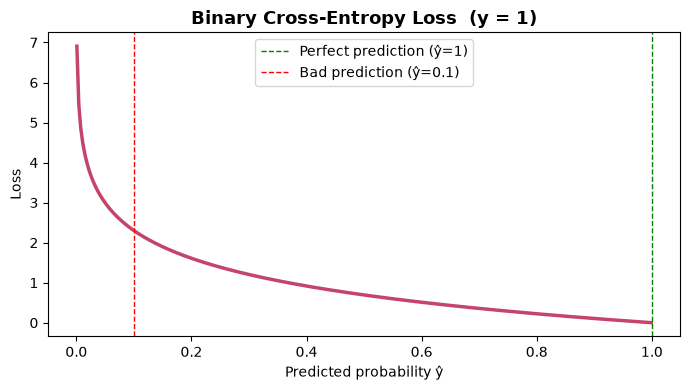

y=1, ŷ=0.95 → loss: 0.0513 ← small, good
y=1, ŷ=0.50 → loss: 0.6931 ← medium
y=1, ŷ=0.10 → loss: 2.3026 ← large, bad


In [65]:
# Binary cross-entropy — شو يصير للـ loss مع تغير الـ prediction
y_true = 1.0
y_pred = np.linspace(0.001, 0.999, 300)
bce    = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

plt.figure(figsize=(7, 4))
plt.plot(y_pred, bce, color="#C44569", linewidth=2.5)
plt.title("Binary Cross-Entropy Loss  (y = 1)",
          fontsize=13, fontweight="bold")
plt.xlabel("Predicted probability ŷ")
plt.ylabel("Loss")
plt.axvline(1.0, color="green",  linestyle="--",
            linewidth=1, label="Perfect prediction (ŷ=1)")
plt.axvline(0.1, color="red",    linestyle="--",
            linewidth=1, label="Bad prediction (ŷ=0.1)")
plt.legend()
plt.tight_layout()
plt.show()

# أمثلة عددية
print("y=1, ŷ=0.95 → loss:", round(-(np.log(0.95)), 4),  "← small, good")
print("y=1, ŷ=0.50 → loss:", round(-(np.log(0.50)), 4),  "← medium")
print("y=1, ŷ=0.10 → loss:", round(-(np.log(0.10)), 4),  "← large, bad")

---

## 10. How to Choose a Loss Function?

The loss function is chosen by the task — not by the data or the
architecture. The rule is the same as for the output activation:

| Task | Loss Function | Output Activation |
|------|---------------|-------------------|
| Binary classification | Binary Cross-Entropy | Sigmoid |
| Multi-class classification | Categorical Cross-Entropy | Softmax |
| Regression | Mean Squared Error (MSE) | None (linear) |

**Key insight:** the output activation and the loss function are
always chosen together — they are two sides of the same decision.
Sigmoid pairs with Binary Cross-Entropy. Softmax pairs with
Categorical Cross-Entropy. A linear output pairs with MSE.

---

## 11. Our Choices for the Heart Disease Project

**Task:** Binary classification — predict whether a patient has
heart disease (1) or not (0).

**Output activation → Sigmoid**
The output layer has one neuron with a sigmoid activation.
It produces a value between 0 and 1, interpreted as the model's
estimated probability that the patient has heart disease.
A threshold of 0.5 converts this probability into a class label.

**Loss function → Binary Cross-Entropy**
Binary cross-entropy is the standard loss for binary classification.
It penalizes confident wrong predictions heavily — exactly the
behavior needed in a medical screening context where a confident
but incorrect prediction could have real consequences.

**Hidden layer activation → ReLU**
ReLU is the default choice for hidden layers. It introduces
non-linearity efficiently and avoids the vanishing gradient
problem that sigmoid and tanh suffer from in deeper networks.

**Summary:**

| Layer | Activation | Reason |
|-------|------------|--------|
| Hidden layers | ReLU | Default — fast, effective, no vanishing gradient |
| Output layer | Sigmoid | Binary task — output is a probability |
| Loss | Binary Cross-Entropy | Standard loss for binary classification |

In [66]:
np.random.seed(42)

# --- Architecture ---
n_input  = 3
n_hidden = 4
n_output = 1

# --- Random weights and biases (as Keras would initialize) ---
W1 = np.random.randn(n_input,  n_hidden) * 0.1   # shape (3, 4)
b1 = np.zeros(n_hidden)                            # shape (4,)

W2 = np.random.randn(n_hidden, n_output) * 0.1   # shape (4, 1)
b2 = np.zeros(n_output)                            # shape (1,)

# --- One sample input (3 features, already scaled) ---
X_sample = np.array([[0.5, -1.2, 0.8]])            # shape (1, 3)

# --- Hidden layer ---
z1 = X_sample @ W1 + b1          # weighted sum
a1 = relu(z1)                     # ReLU activation

# --- Output layer ---
z2 = a1 @ W2 + b2                 # weighted sum
y_hat = sigmoid(z2)               # Sigmoid → probability

# --- Results ---
print("Input X        :", X_sample)
print()
print("Hidden layer")
print("  z1 (raw)     :", z1.round(4))
print("  a1 (ReLU)    :", a1.round(4))
print()
print("Output layer")
print("  z2 (raw)     :", z2.round(4))
print("  ŷ (sigmoid)  :", y_hat.round(4))
print()
if y_hat[0, 0] >= 0.5:
    print("Prediction: Heart Disease (1)")
else:
    print("Prediction: No Heart Disease (0)")
print(f"Confidence   : {y_hat[0,0]:.1%}")

Input X        : [[ 0.5 -1.2  0.8]]

Hidden layer
  z1 (raw)     : [[ 0.0154  0.0646 -0.1942 -0.0532]]
  a1 (ReLU)    : [[0.0154 0.0646 0.     0.    ]]

Output layer
  z2 (raw)     : [[-0.012]]
  ŷ (sigmoid)  : [[0.497]]

Prediction: No Heart Disease (0)
Confidence   : 49.7%


---

## 13. Summary — What I Learned Today

**Activation Functions**

| Function | Range | Use |
|----------|-------|-----|
| ReLU | [0, +∞) | Hidden layers — default choice |
| Sigmoid | [0, 1] | Output layer — binary classification |
| Tanh | [−1, +1] | Hidden layers — zero-centered alternative |
| Softmax | [0, 1] sum=1 | Output layer — multi-class classification |

Without activation functions, a neural network collapses into a
single linear model regardless of its depth.

**Forward Propagation**
Data flows forward through the network layer by layer:
weighted sum → activation → next layer → ... → output.
This is how the network makes a prediction.

**Loss Functions**
The loss measures how wrong the prediction is.
Binary Cross-Entropy is the correct loss for this project.

**Our project choices:**
- Hidden layers → ReLU
- Output layer → Sigmoid
- Loss → Binary Cross-Entropy

Tomorrow (Day 3): how the network uses the loss to update its
weights — backpropagation, gradient descent, and optimizers.